In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# define file paths 
RAW_TWEET_PATH = "../data/raw/raw_tweets.csv"
TWEET_PATH = "../data/processed/clean_tweets.csv"
MODEL_TABLE_PATH = "../data/results/modelling_table.csv"
MNLG_TABLE_PATH = "../data/results/mn_logreg_evaluation.csv"
RF_TABLE_PATH = "../data/results/rf_evaluation.csv"
GB_TABLE_PATH = "../data/results/gb_evaluation.csv"

# load datasets 
raw_df = pd.read_csv(RAW_TWEET_PATH)
model_df = pd.read_csv(MODEL_TABLE_PATH, index_col="date")  # main modelling table with sentiment and returns
mnlg_df = pd.read_csv(MNLG_TABLE_PATH)  # multinomial logistic regression evaluation metrics
rf_df = pd.read_csv(RF_TABLE_PATH)  # random forest evaluation metrics
gb_df = pd.read_csv(GB_TABLE_PATH)  # gradient boost evaluation metrics
tweet_df = pd.read_csv(TWEET_PATH) # scored tweets

## Exploratory Data Analysis 
This notebook will explore the modelling table of financial and social data to explore its relationships and patterns

### Cleaning QA

In [3]:
sample_idx = raw_df.sample(5).index
with pd.option_context('display.max_colwidth', None):
    display(pd.concat([raw_df.loc[sample_idx, ["text"]], tweet_df.loc[sample_idx, ["text"]]]))

,text
872092,sp500 fut ... https://t.co/bAC3tMVVgH
689035,RT @NorthmanTrader: Just curious: What is $FB's business model without advertisers?
841415,Disney | $DIS\n\nDisney Symmetrical Triangle\n\nLong or short it with BTC on Trade8: https://t.co/tHxzmmlU1W https://t.co/B1p3aFGoRO
714172,$eth We have detected a noticeable rise in the Zeitgeist for Ethan Allen Interiors Inc. at https://t.co/TPxwjq4L6R\nVisit DataSwarm Markets for more information\n#STOCKS #NYSE\nDataSwarm ref: 103310
737445,"Today Top Flow in #technology sector, Buy Flow &amp; Sell Flow $AAPL $GOOGL $MSFT $VZ $AKAM $ACN $QCOM $MU $KLAC $ADSK $NVDA $T $FB $ORCL $V $GOOG $CRM $CSCO $MA $INTC #stock #stocks #StockMarket #Investment #investing https://t.co/Gr3YvQytXq https://t.co/8fuhROm852"
872092,sp500 fut
689035,rt just curious what is $fb s business model without advertisers
841415,disney $dis disney symmetrical triangle long or short it with btc on trade8
714172,$eth we have detected a noticeable rise in the zeitgeist for ethan allen interiors inc at visit dataswarm markets for more information stocks nyse dataswarm ref 103310
737445,today top flow in technology sector buy flow amp sell flow $aapl $googl $msft $vz $akam $acn $qcom $mu $klac $adsk $nvda $t $fb $orcl $v $goog $crm $csco $ma $intc stock stocks stockmarket investment investing


### Sentiment Scoring QA
Select 100 random tweets containing the word "grow" and 100 containing "fall" and compute average sentiment scores in order to assess the quality of scores 

In [4]:
test_df = tweet_df.sample(5)
with pd.option_context('display.max_colwidth', None):
    display(test_df.head())

,timestamp,text,fb_score
280421,2020-05-05 13:14:08+00:00,eop option trade of the day $btc $msft $fb $nvda $bynd $twlo $bkng $amzn $googl $bidu $baba $dis $aapl $gs $tsla $nflx $amd $ba $crm $lulu $roku,0.450583
558584,2020-06-18 16:49:00+00:00,date 06 18 2020 time 12 45 pm ticker $ba exp 06 26 20 strike 192 5 spot 191 08 contracts 308 10 00 premium $308k type sweep trading inversion nasdaq covid19 stocks fed $roku $amzn $apple $sq $spy $qqq $iwm $spot,0.054932
654732,2020-06-26 21:30:22+00:00,rt today s profit $1410 $spy $spx $tsla $ba $amzn daytrading news invest investing finance money life newyork wallstre,0.123537
281786,2020-05-05 10:44:57+00:00,q4 2020 eps estimates for medallion financial corp decreased by b riley $mfin stocks,-0.925093
797068,2020-07-08 18:48:12+00:00,and the infuriating thing is that trump apologists will claim nobody was swayed by this fb content they conveniently ignore the fact that $fb is valued at $500b on wall street entirely based on its ability to influence minds via content,-0.467701


In [5]:
pos_df = tweet_df.loc[tweet_df["text"].str.contains("rise", na=False)]

test_df = pos_df.sample(100)
display (test_df.head())

mean_score = round(test_df["fb_score"].mean(), 6)

print(f"Arithmetic Mean finBERT score of results: {mean_score}")

,timestamp,text,fb_score
221104,2020-04-28 21:39:10+00:00,predictably the momentum folks probably gettin...,0.177178
631984,2020-06-24 14:49:37+00:00,$es_u if you are wildly bullish get your ass i...,-0.395976
868279,2020-07-13 13:27:36+00:00,rt this is what to know before you start your ...,0.062696
675865,2020-06-27 01:30:02+00:00,$play we have detected a noticeable rise in th...,0.372161
242940,2020-04-29 16:09:53+00:00,wednesday another covid casualty rises from th...,0.900703


Arithmetic Mean finBERT score of results: 0.25342


In [6]:
neg_df = tweet_df[tweet_df["text"].str.contains("fall", na=False)]

test_df = neg_df.sample(100)
display(test_df.head())

mean_score = round(test_df["fb_score"].mean(), 6)

print(f"Arithmetic Mean finBERT score of results: {mean_score}")

,timestamp,text,fb_score
556055,2020-06-18 20:14:28+00:00,rt that s censorship if you continue to apply ...,0.007017
391168,2020-06-03 17:53:57+00:00,rt no cheating let s see how good you are the ...,-0.089680
348252,2020-05-29 15:03:00+00:00,german retail sales fall much less than foreca...,-0.964665
553754,2020-06-17 01:03:10+00:00,rt that s censorship if you continue to apply ...,0.007017
802548,2020-07-08 13:28:08+00:00,rt $spx bullish sentiment at 91% extreme with ...,-0.354874


Arithmetic Mean finBERT score of results: -0.412179


### Modelling Table Visualizations

#### Time Series of Sentiment Scores

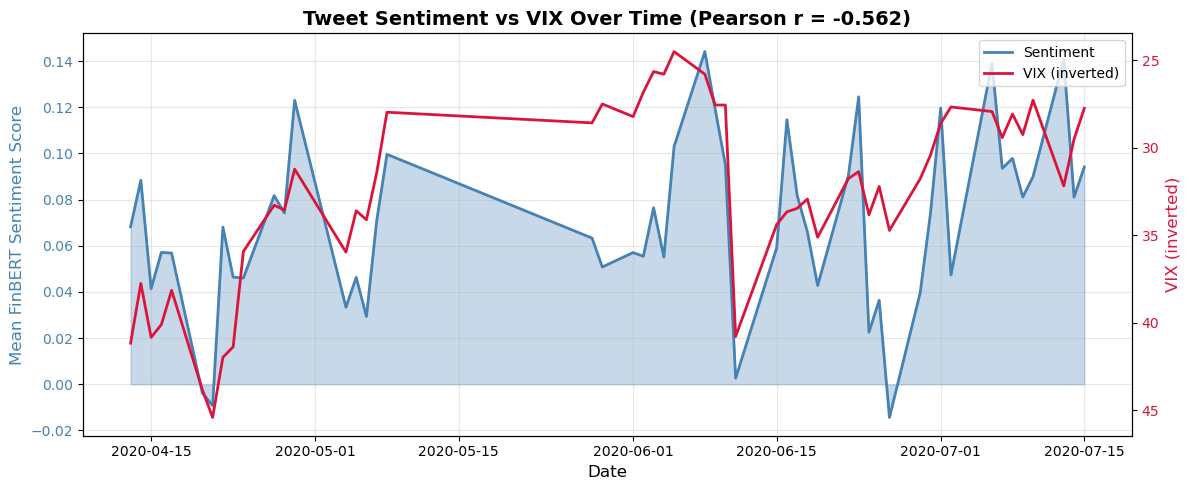

In [7]:
# convert date index to datetime for proper plotting
model_df.index = pd.to_datetime(model_df.index)

# calculate Pearson correlation between sentiment and VIX
pearson_corr = model_df['mean_fb_score'].corr(model_df['VIX'])

# create time series plot with dual y-axes
fig, ax1 = plt.subplots(figsize=(12, 5))

# plot sentiment on left axis
ax1.plot(model_df.index, model_df['mean_fb_score'], linewidth=2, color='steelblue', label='Sentiment')
ax1.fill_between(model_df.index, model_df['mean_fb_score'], alpha=0.3, color='steelblue')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Mean FinBERT Sentiment Score', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# plot VIX on right axis (inverted)
ax2 = ax1.twinx()
ax2.plot(model_df.index, model_df['VIX'], linewidth=2, color='crimson', label='VIX (inverted)')
ax2.set_ylabel('VIX (inverted)', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.invert_yaxis()

# add title with Pearson correlation and combined legend
ax1.set_title(f'Tweet Sentiment vs VIX Over Time (Pearson r = {pearson_corr:.3f})', fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

#### Sector-Sentiment Correlation

## Model Evaluation and Comparison 

### Logistic Regression Evaluation
#### Accuracy Across Sectors

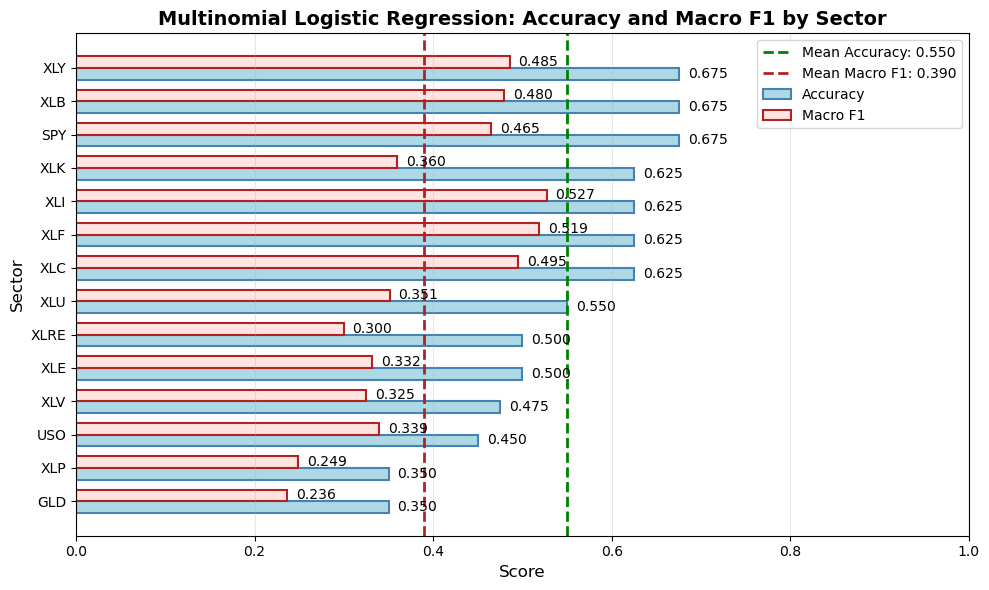

In [14]:
# sort sectors by accuracy 
sorted_df = mnlg_df.sort_values('accuracy_mean', ascending=True)

y_positions = list(range(len(sorted_df)))
bar_height = 0.35

# create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
acc_bars = ax.barh(
    [y - bar_height / 2 for y in y_positions],
    sorted_df['accuracy_mean'],
    height=bar_height,
    color='lightblue',
    edgecolor='steelblue',
    linewidth=1.5,
    label='Accuracy'
)
f1_bars = ax.barh(
    [y + bar_height / 2 for y in y_positions],
    sorted_df['f1_macro_mean'],
    height=bar_height,
    color='mistyrose',
    edgecolor='firebrick',
    linewidth=1.5,
    label='Macro F1'
)

# add score labels to each bar
for i, (accuracy, f1_score) in enumerate(zip(sorted_df['accuracy_mean'], sorted_df['f1_macro_mean'])):
    ax.text(accuracy + 0.01, y_positions[i] - bar_height / 2, f'{accuracy:.3f}', va='center', fontsize=10)
    ax.text(f1_score + 0.01, y_positions[i] + bar_height / 2, f'{f1_score:.3f}', va='center', fontsize=10)

# add vertical lines showing mean scores
mean_accuracy = mnlg_df['accuracy_mean'].mean()
mean_f1 = mnlg_df['f1_macro_mean'].mean()
ax.axvline(mean_accuracy, color='green', linestyle='--', linewidth=2, label=f'Mean Accuracy: {mean_accuracy:.3f}')
ax.axvline(mean_f1, color='firebrick', linestyle='--', linewidth=2, label=f'Mean Macro F1: {mean_f1:.3f}')

# format axes and add labels
ax.set_yticks(y_positions)
ax.set_yticklabels(sorted_df['ticker'])
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Sector', fontsize=12)
ax.set_title('Multinomial Logistic Regression: Accuracy and Macro F1 by Sector', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

#### Confusion Matrices by Sector

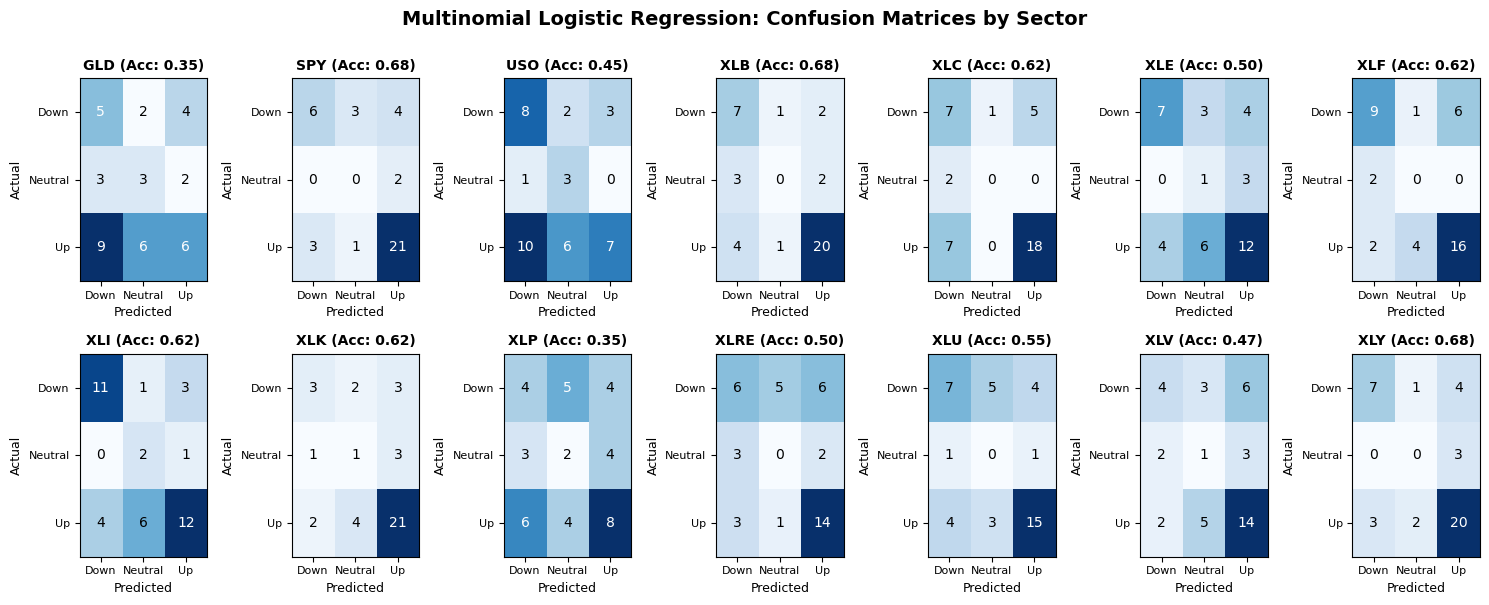

In [9]:
# extract confusion matrix columns and define class labels
cm_cols = [col for col in mnlg_df.columns if col.startswith('cm_')]
class_labels = ['Down', 'Neutral', 'Up']

# create grid of subplots 
fig, axes = plt.subplots(2, 7, figsize=(15, 6))
axes = axes.flatten()

# generate a confusion matrix heatmap for each sector
for idx, row in mnlg_df.iterrows():
    ax = axes[idx]
    
    # put the confusion matrix values into a 3x3 grid
    cm = np.array([row[col] for col in cm_cols]).reshape(3, 3)
    
    # create heatmap with blue colors
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    
    # set axis ticks and labels
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    ax.set_xticklabels(class_labels, fontsize=8)
    ax.set_yticklabels(class_labels, fontsize=8)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    
    # add count annotations to each cell
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, int(cm[i, j]), ha="center", va="center", 
                          color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=10)
    
    # add sector name and accuracy to subplot title
    ax.set_title(f'{row["ticker"]} (Acc: {row["accuracy_mean"]:.2f})', fontsize=10, fontweight='bold')

plt.suptitle('Multinomial Logistic Regression: Confusion Matrices by Sector', fontsize=14, fontweight='bold', y=1.00)
fig.tight_layout()
plt.show()

### Random Forest Evaluation

#### Accuracy Across Sectors

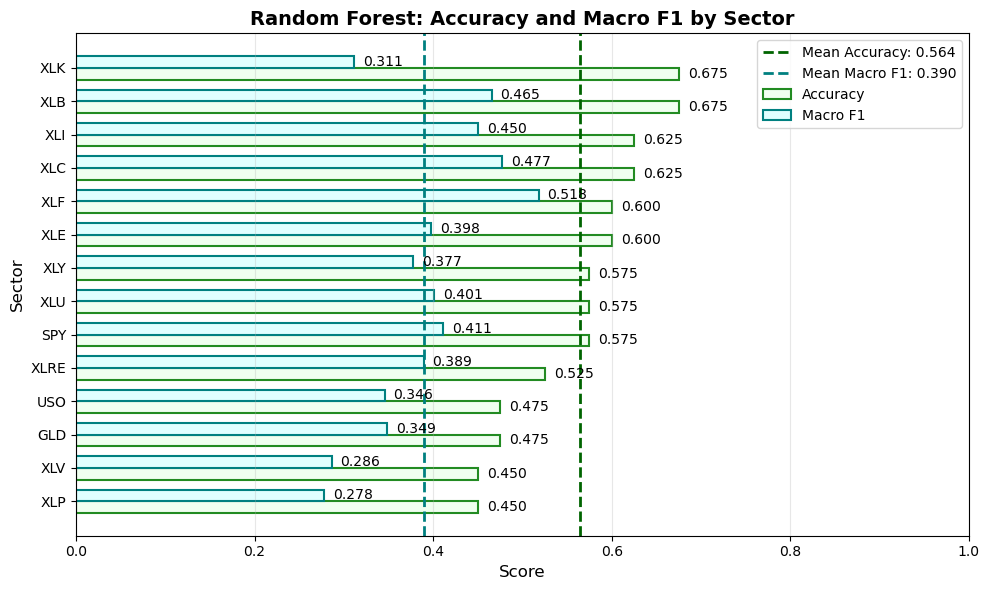

In [15]:
# sort sectors by accuracy 
sorted_df = rf_df.sort_values('accuracy_mean', ascending=True)

y_positions = list(range(len(sorted_df)))
bar_height = 0.35

# create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
acc_bars = ax.barh(
    [y - bar_height / 2 for y in y_positions],
    sorted_df['accuracy_mean'],
    height=bar_height,
    color='honeydew',
    edgecolor='forestgreen',
    linewidth=1.5,
    label='Accuracy'
)
f1_bars = ax.barh(
    [y + bar_height / 2 for y in y_positions],
    sorted_df['f1_macro_mean'],
    height=bar_height,
    color='lightcyan',
    edgecolor='teal',
    linewidth=1.5,
    label='Macro F1'
)

# add score labels to each bar
for i, (accuracy, f1_score) in enumerate(zip(sorted_df['accuracy_mean'], sorted_df['f1_macro_mean'])):
    ax.text(accuracy + 0.01, y_positions[i] - bar_height / 2, f'{accuracy:.3f}', va='center', fontsize=10)
    ax.text(f1_score + 0.01, y_positions[i] + bar_height / 2, f'{f1_score:.3f}', va='center', fontsize=10)

# add vertical lines showing mean scores
mean_accuracy = rf_df['accuracy_mean'].mean()
mean_f1 = rf_df['f1_macro_mean'].mean()
ax.axvline(mean_accuracy, color='darkgreen', linestyle='--', linewidth=2, label=f'Mean Accuracy: {mean_accuracy:.3f}')
ax.axvline(mean_f1, color='teal', linestyle='--', linewidth=2, label=f'Mean Macro F1: {mean_f1:.3f}')

# format axes and add labels
ax.set_yticks(y_positions)
ax.set_yticklabels(sorted_df['ticker'])
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Sector', fontsize=12)
ax.set_title('Random Forest: Accuracy and Macro F1 by Sector', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

#### Confusion Matrices by Sector

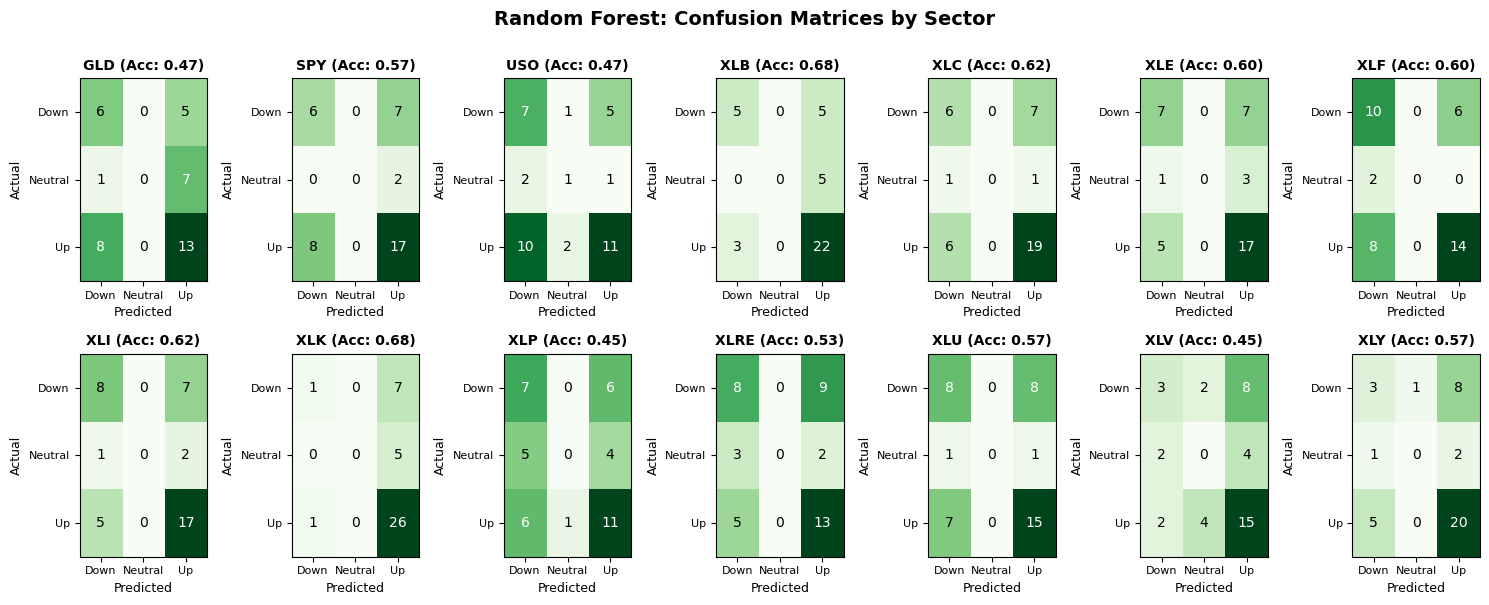

In [11]:
# extract confusion matrix columns and define class labels
cm_cols = [col for col in rf_df.columns if col.startswith('cm_')]
class_labels = ['Down', 'Neutral', 'Up']

# create grid of subplots 
fig, axes = plt.subplots(2, 7, figsize=(15, 6))
axes = axes.flatten()

# generate a confusion matrix heatmap for each sector
for idx, row in rf_df.iterrows():
    ax = axes[idx]
    
    # put the confusion matrix values into a 3x3 grid
    cm = np.array([row[col] for col in cm_cols]).reshape(3, 3)
    
    # create heatmap with green colors to differentiate from logistic regression
    im = ax.imshow(cm, cmap='Greens', aspect='auto')
    
    # set axis ticks and labels
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    ax.set_xticklabels(class_labels, fontsize=8)
    ax.set_yticklabels(class_labels, fontsize=8)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    
    # add count annotations to each cell
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, int(cm[i, j]), ha="center", va="center", 
                          color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=10)
    
    # add sector name and accuracy to subplot title
    ax.set_title(f'{row["ticker"]} (Acc: {row["accuracy_mean"]:.2f})', fontsize=10, fontweight='bold')

plt.suptitle('Random Forest: Confusion Matrices by Sector', fontsize=14, fontweight='bold', y=1.00)
fig.tight_layout()
plt.show()

### Gradient Boost Evaluation

#### Accuracy Across Sectors

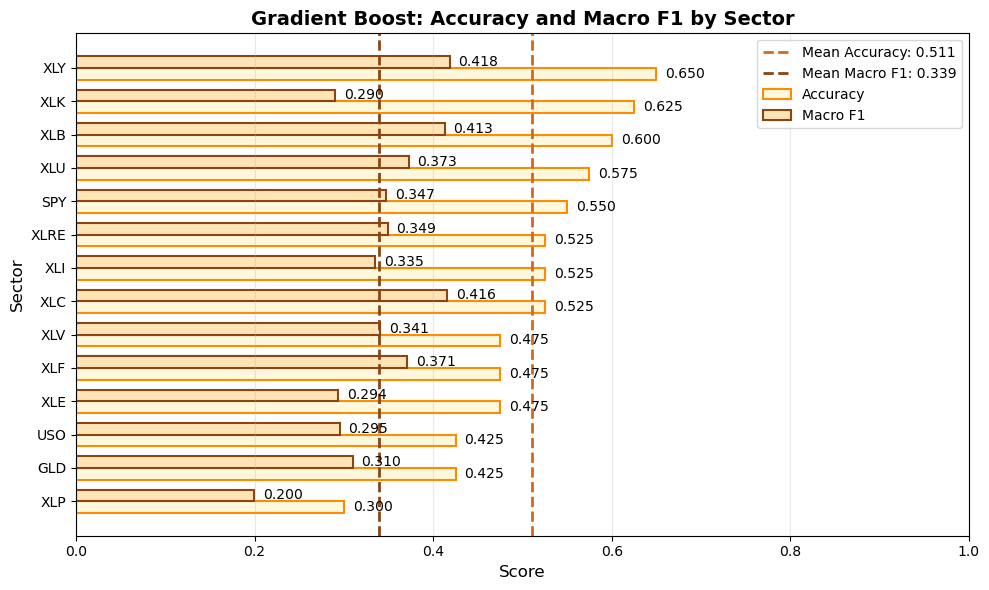

In [16]:
# sort sectors by accuracy 
sorted_df = gb_df.sort_values('accuracy_mean', ascending=True)

y_positions = list(range(len(sorted_df)))
bar_height = 0.35

# create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
acc_bars = ax.barh(
    [y - bar_height / 2 for y in y_positions],
    sorted_df['accuracy_mean'],
    height=bar_height,
    color='cornsilk',
    edgecolor='darkorange',
    linewidth=1.5,
    label='Accuracy'
)
f1_bars = ax.barh(
    [y + bar_height / 2 for y in y_positions],
    sorted_df['f1_macro_mean'],
    height=bar_height,
    color='moccasin',
    edgecolor='saddlebrown',
    linewidth=1.5,
    label='Macro F1'
)

# add score labels to each bar
for i, (accuracy, f1_score) in enumerate(zip(sorted_df['accuracy_mean'], sorted_df['f1_macro_mean'])):
    ax.text(accuracy + 0.01, y_positions[i] - bar_height / 2, f'{accuracy:.3f}', va='center', fontsize=10)
    ax.text(f1_score + 0.01, y_positions[i] + bar_height / 2, f'{f1_score:.3f}', va='center', fontsize=10)

# add vertical lines showing mean scores
mean_accuracy = gb_df['accuracy_mean'].mean()
mean_f1 = gb_df['f1_macro_mean'].mean()
ax.axvline(mean_accuracy, color='chocolate', linestyle='--', linewidth=2, label=f'Mean Accuracy: {mean_accuracy:.3f}')
ax.axvline(mean_f1, color='saddlebrown', linestyle='--', linewidth=2, label=f'Mean Macro F1: {mean_f1:.3f}')

# format axes and add labels
ax.set_yticks(y_positions)
ax.set_yticklabels(sorted_df['ticker'])
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Sector', fontsize=12)
ax.set_title('Gradient Boost: Accuracy and Macro F1 by Sector', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

#### Confusion Matrices by Sector

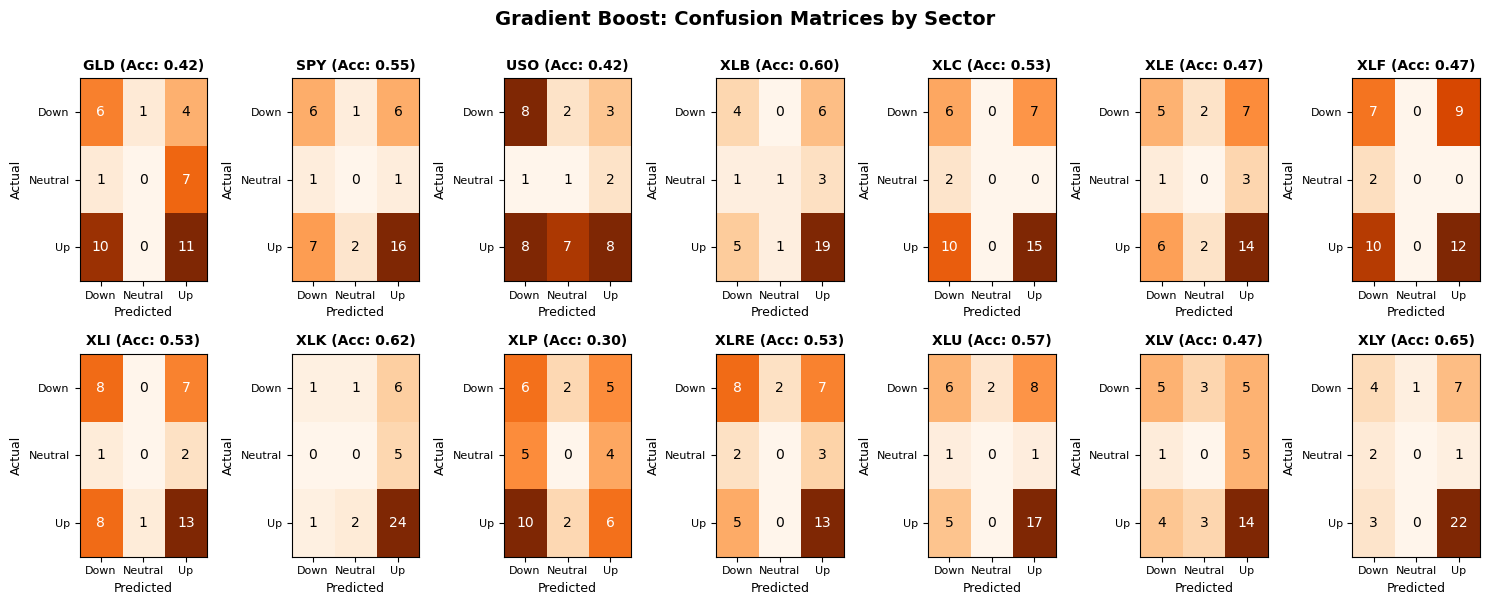

In [13]:
# extract confusion matrix columns and define class labels
cm_cols = [col for col in gb_df.columns if col.startswith('cm_')]
class_labels = ['Down', 'Neutral', 'Up']

# create grid of subplots 
fig, axes = plt.subplots(2, 7, figsize=(15, 6))
axes = axes.flatten()

# generate a confusion matrix heatmap for each sector
for idx, row in gb_df.iterrows():
    ax = axes[idx]
    
    # put the confusion matrix values into a 3x3 grid
    cm = np.array([row[col] for col in cm_cols]).reshape(3, 3)
    
    # create heatmap with orange colors to differentiate from other models
    im = ax.imshow(cm, cmap='Oranges', aspect='auto')
    
    # set axis ticks and labels
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    ax.set_xticklabels(class_labels, fontsize=8)
    ax.set_yticklabels(class_labels, fontsize=8)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    
    # add count annotations to each cell
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, int(cm[i, j]), ha="center", va="center", 
                          color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=10)
    
    # add sector name and accuracy to subplot title
    ax.set_title(f'{row["ticker"]} (Acc: {row["accuracy_mean"]:.2f})', fontsize=10, fontweight='bold')

plt.suptitle('Gradient Boost: Confusion Matrices by Sector', fontsize=14, fontweight='bold', y=1.00)
fig.tight_layout()
plt.show()